# Compare TC Metrics: ASCAT+SMAP vs ASCAT+SMOS-IC

This notebook compares TC-derived model metrics between two observation-pair approaches:
- ASCAT + SMAP (`ASCL4_SMPL3`)
- ASCAT + SMOS-IC (`ASCL4_SMOSIC`)

Metrics compared:
- `anomR` (`R_mod_*` field)
- `R2` (`R2_TC_mod`)
- `sigma2` (`sigma2_mod`)

For each metric, maps show:
1. `DA - OL` for ASCAT+SMAP
2. `DA - OL` for ASCAT+SMOS-IC
3. Difference between approaches: `(DA-OL)_SMOSIC - (DA-OL)_SMAP`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Inputs (4 TC files) ----
SMAP_OL_FILE = Path('/Users/amfox/Desktop/geosldas-analysis/projects/cygnss_da/notebooks/cygnss_da_combined_inputs/ASCL4_SMPL3_CNTL_TC_stats_201808_202405.mat')
SMAP_DA_FILE = Path('/Users/amfox/Desktop/geosldas-analysis/projects/cygnss_da/notebooks/cygnss_da_combined_inputs/ASCL4_SMPL3_CYG_DA_TC_stats_201808_202405.mat')
SMOS_OL_FILE = Path('/Users/amfox/Desktop/SMOS_IC/ASCL4_SMOSIC_OLv8_M36_cd_TC_stats_201808_202405.mat')
SMOS_DA_FILE = Path('/Users/amfox/Desktop/SMOS_IC/ASCL4_SMOSIC_DAv8_M36_cd_TC_stats_201808_202405.mat')

N_LON = 964
N_LAT = 406
CYGNSS_EXTENT = [-140, 180, -40, 40]
CYGNSS_DOMAIN_MASK = None  # populated after lat/lon grids are loaded

# Figure-6 comparability settings
NMIN_OVERRIDE = 50
# Figure 6 computes mean/std from full valid TC field, not CYGNSS-clipped field.
STATS_ON_FULL_VALID_DOMAIN = True

for p in [SMAP_OL_FILE, SMAP_DA_FILE, SMOS_OL_FILE, SMOS_DA_FILE]:
    if not p.exists():
        raise FileNotFoundError(p)

print('Using files:')
for p in [SMAP_OL_FILE, SMAP_DA_FILE, SMOS_OL_FILE, SMOS_DA_FILE]:
    print(' -', p)
print(f'NMIN_OVERRIDE={NMIN_OVERRIDE}')


Using files:
 - /Users/amfox/Desktop/geosldas-analysis/projects/cygnss_da/notebooks/cygnss_da_combined_inputs/ASCL4_SMPL3_CNTL_TC_stats_201808_202405.mat
 - /Users/amfox/Desktop/geosldas-analysis/projects/cygnss_da/notebooks/cygnss_da_combined_inputs/ASCL4_SMPL3_CYG_DA_TC_stats_201808_202405.mat
 - /Users/amfox/Desktop/SMOS_IC/ASCL4_SMOSIC_OLv8_M36_cd_TC_stats_201808_202405.mat
 - /Users/amfox/Desktop/SMOS_IC/ASCL4_SMOSIC_DAv8_M36_cd_TC_stats_201808_202405.mat
NMIN_OVERRIDE=50


In [2]:
def _vec(x):
    return np.asarray(x, dtype=float).reshape(-1)


def vec_to_grid(v, nlon=N_LON, nlat=N_LAT):
    v = _vec(v)
    if v.size != nlon * nlat:
        raise ValueError(f'Expected {nlon*nlat} values, got {v.size}')
    # MATLAB column-major flatten -> [lat, lon] for plotting
    return v.reshape((nlon, nlat), order='F').T


def load_tc(path: Path):
    M = loadmat(path, squeeze_me=True, struct_as_record=False)
    keys = {k for k in M.keys() if not k.startswith('__')}

    nmin_file = int(np.asarray(M.get('Nmin', 50)).reshape(-1)[0])
    out = {
        'path': path,
        'keys': keys,
        'Nmin_file': nmin_file,
        'Nmin': int(NMIN_OVERRIDE),
        'lons': vec_to_grid(M['lons']),
        'lats': vec_to_grid(M['lats']),
        'N_sm': vec_to_grid(M['N_sm']),
        'raw': M,
    }
    return out


def metric_field(metric_name: str, approach: str) -> str:
    metric_name = metric_name.lower()
    approach = approach.lower()

    if metric_name == 'anomr':
        if approach == 'smap':
            return 'R_mod_L3'
        if approach == 'smos':
            return 'R_mod_SMOS'
        raise ValueError(f'Unknown approach: {approach}')
    if metric_name == 'r2':
        return 'R2_TC_mod'
    if metric_name == 'sigma2':
        return 'sigma2_mod'

    raise ValueError(f'Unsupported metric: {metric_name}')


def get_metric_grid(tc_dict, metric_name: str, approach: str):
    fld = metric_field(metric_name, approach)
    if fld not in tc_dict['keys']:
        raise KeyError(f"{fld} missing in {tc_dict['path']}")
    return vec_to_grid(tc_dict['raw'][fld])


def clamp01(a):
    out = np.asarray(a, dtype=float).copy()
    out[(out <= 0) | (~np.isfinite(out))] = np.nan
    out[out > 1] = 1.0
    return out


def common_valid_mask(tc_ol, tc_da):
    # Figure-6-style base mask: N_sm threshold + finite R2/sigma2 fields
    r20 = get_metric_grid(tc_ol, 'R2', 'smap' if 'SMPL3' in tc_ol['path'].name else 'smos')
    r21 = get_metric_grid(tc_da, 'R2', 'smap' if 'SMPL3' in tc_da['path'].name else 'smos')
    s20 = get_metric_grid(tc_ol, 'sigma2', 'smap' if 'SMPL3' in tc_ol['path'].name else 'smos')
    s21 = get_metric_grid(tc_da, 'sigma2', 'smap' if 'SMPL3' in tc_da['path'].name else 'smos')

    return (
        (tc_ol['N_sm'] >= tc_ol['Nmin'])
        & (tc_da['N_sm'] >= tc_da['Nmin'])
        & np.isfinite(r20) & np.isfinite(r21)
        & np.isfinite(s20) & np.isfinite(s21)
    )


def paired_metric_delta(tc_ol, tc_da, metric_name: str, approach: str):
    metric_name = metric_name.lower()
    base_valid = common_valid_mask(tc_ol, tc_da)

    if metric_name == 'r2':
        ol = clamp01(get_metric_grid(tc_ol, 'R2', approach))
        da = clamp01(get_metric_grid(tc_da, 'R2', approach))
        d = da - ol  # Figure 6 convention for R2
        label_main = 'DA-OL'
        valid = base_valid & np.isfinite(ol) & np.isfinite(da)

    elif metric_name == 'sigma2':
        ol = get_metric_grid(tc_ol, 'sigma2', approach)
        da = get_metric_grid(tc_da, 'sigma2', approach)
        d = ol - da  # Figure 6 sign convention: positive = improvement
        label_main = 'OL-DA'
        valid = base_valid & np.isfinite(ol) & np.isfinite(da)

    elif metric_name == 'anomr':
        ol = get_metric_grid(tc_ol, 'anomR', approach)
        da = get_metric_grid(tc_da, 'anomR', approach)
        d = da - ol  # keep DA-OL for anomR
        label_main = 'DA-OL'
        valid = base_valid & np.isfinite(ol) & np.isfinite(da)

    else:
        raise ValueError(metric_name)

    d = np.where(valid, d, np.nan)
    return d, valid, label_main


def masked_stats(arr):
    x = np.asarray(arr, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {'n': 0, 'mean': np.nan, 'median': np.nan, 'p05': np.nan, 'p95': np.nan}
    return {
        'n': int(x.size),
        'mean': float(np.mean(x)),
        'median': float(np.median(x)),
        'p05': float(np.percentile(x, 5)),
        'p95': float(np.percentile(x, 95)),
    }


def robust_abs_limit(arr, q=99, floor=1e-6):
    x = np.abs(np.asarray(arr, dtype=float))
    x = x[np.isfinite(x)]
    if x.size == 0:
        return floor
    return max(float(np.percentile(x, q)), floor)


def spatial_mean_std(arr):
    x = np.asarray(arr, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    return float(np.mean(x)), float(np.std(x))


def mean_pm_std_text(arr, fmt_mean='+.4f', fmt_std='.4f', suffix=''):
    m, sd = spatial_mean_std(arr)
    return f"{format(m, fmt_mean)} ± {format(sd, fmt_std)}{suffix}"


def setup_map(ax, title):
    ax.set_title(title)
    ax.set_extent(CYGNSS_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.gridlines(crs=ccrs.PlateCarree(), linewidth=0.2, color='0.7', alpha=0.6)
    ax.set_xticks([])
    ax.set_yticks([])


In [3]:
tc_smap_ol = load_tc(SMAP_OL_FILE)
tc_smap_da = load_tc(SMAP_DA_FILE)
tc_smos_ol = load_tc(SMOS_OL_FILE)
tc_smos_da = load_tc(SMOS_DA_FILE)

# sanity checks on shared geometry
for name, tc in [
    ('SMAP OL', tc_smap_ol),
    ('SMAP DA', tc_smap_da),
    ('SMOS OL', tc_smos_ol),
    ('SMOS DA', tc_smos_da),
]:
    print(f"{name:8s} | Nmin_file={tc['Nmin_file']:>3d} | Nmin_used={tc['Nmin']:>3d} | grid={tc['lats'].shape}")

lon_ref = tc_smap_ol['lons']
lat_ref = tc_smap_ol['lats']
for tc in [tc_smap_da, tc_smos_ol, tc_smos_da]:
    if not np.allclose(tc['lons'], lon_ref, atol=1e-6, equal_nan=True):
        raise RuntimeError('Longitude grids differ across files')
    if not np.allclose(tc['lats'], lat_ref, atol=1e-6, equal_nan=True):
        raise RuntimeError('Latitude grids differ across files')

lon_grid = lon_ref
lat_grid = lat_ref
x0, x1, y0, y1 = CYGNSS_EXTENT
CYGNSS_DOMAIN_MASK = (lon_grid >= x0) & (lon_grid <= x1) & (lat_grid >= y0) & (lat_grid <= y1)
print('Shared grid confirmed.')
print(f'CYGNSS domain cells: {int(np.sum(CYGNSS_DOMAIN_MASK)):,}')


SMAP OL  | Nmin_file= 20 | Nmin_used= 50 | grid=(406, 964)
SMAP DA  | Nmin_file= 20 | Nmin_used= 50 | grid=(406, 964)
SMOS OL  | Nmin_file= 20 | Nmin_used= 50 | grid=(406, 964)
SMOS DA  | Nmin_file= 20 | Nmin_used= 50 | grid=(406, 964)
Shared grid confirmed.
CYGNSS domain cells: 224,534


In [4]:
metrics = ['anomR', 'R2', 'sigma2']

results = {}
rows = []

for metric in metrics:
    d_smap_full, valid_smap, label_main = paired_metric_delta(tc_smap_ol, tc_smap_da, metric, 'smap')
    d_smos_full, valid_smos, _ = paired_metric_delta(tc_smos_ol, tc_smos_da, metric, 'smos')

    common_full = valid_smap & valid_smos & np.isfinite(d_smap_full) & np.isfinite(d_smos_full)
    d_between_full = np.where(common_full, d_smos_full - d_smap_full, np.nan)

    # Plot remains CYGNSS-domain-only per your plotting preference
    d_smap_plot = np.where(CYGNSS_DOMAIN_MASK, d_smap_full, np.nan)
    d_smos_plot = np.where(CYGNSS_DOMAIN_MASK, d_smos_full, np.nan)
    d_between_plot = np.where(CYGNSS_DOMAIN_MASK, d_between_full, np.nan)

    results[metric] = {
        'd_smap_full': d_smap_full,
        'd_smos_full': d_smos_full,
        'd_between_full': d_between_full,
        'd_smap_plot': d_smap_plot,
        'd_smos_plot': d_smos_plot,
        'd_between_plot': d_between_plot,
        'valid_smap': valid_smap,
        'valid_smos': valid_smos,
        'common_full': common_full,
        'label_main': label_main,
    }

    # Figure-6 comparability: stats from full valid field
    rows.append({'metric': metric, 'map': f'{label_main} (ASCAT+SMAP)', **masked_stats(d_smap_full)})
    rows.append({'metric': metric, 'map': f'{label_main} (ASCAT+SMOS)', **masked_stats(d_smos_full)})
    rows.append({'metric': metric, 'map': f'({label_main})_SMOS - ({label_main})_SMAP', **masked_stats(d_between_full)})

summary = pd.DataFrame(rows)
summary


,metric,map,n,mean,median,p05,p95
0,anomR,DA-OL (ASCAT+SMAP),47683,0.029161,2.147602e-02,-0.001390,0.085760
1,anomR,DA-OL (ASCAT+SMOS),47500,0.024838,1.814044e-02,-0.002425,0.075122
2,anomR,(DA-OL)_SMOS - (DA-OL)_SMAP,45920,-0.004344,-2.398729e-03,-0.024005,0.010208
3,R2,DA-OL (ASCAT+SMAP),47683,0.039180,2.734840e-02,-0.015151,0.137582
4,R2,DA-OL (ASCAT+SMOS),47500,0.035967,2.459703e-02,-0.017390,0.130859
5,R2,(DA-OL)_SMOS - (DA-OL)_SMAP,45920,-0.003183,-9.888596e-04,-0.034746,0.025162
6,sigma2,OL-DA (ASCAT+SMAP),47683,0.000080,4.510314e-05,-0.000012,0.000334
7,sigma2,OL-DA (ASCAT+SMOS),47500,0.000078,4.274580e-05,-0.000012,0.000320
8,sigma2,(OL-DA)_SMOS - (OL-DA)_SMAP,45920,-0.000006,-8.109298e-07,-0.000046,0.000034


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

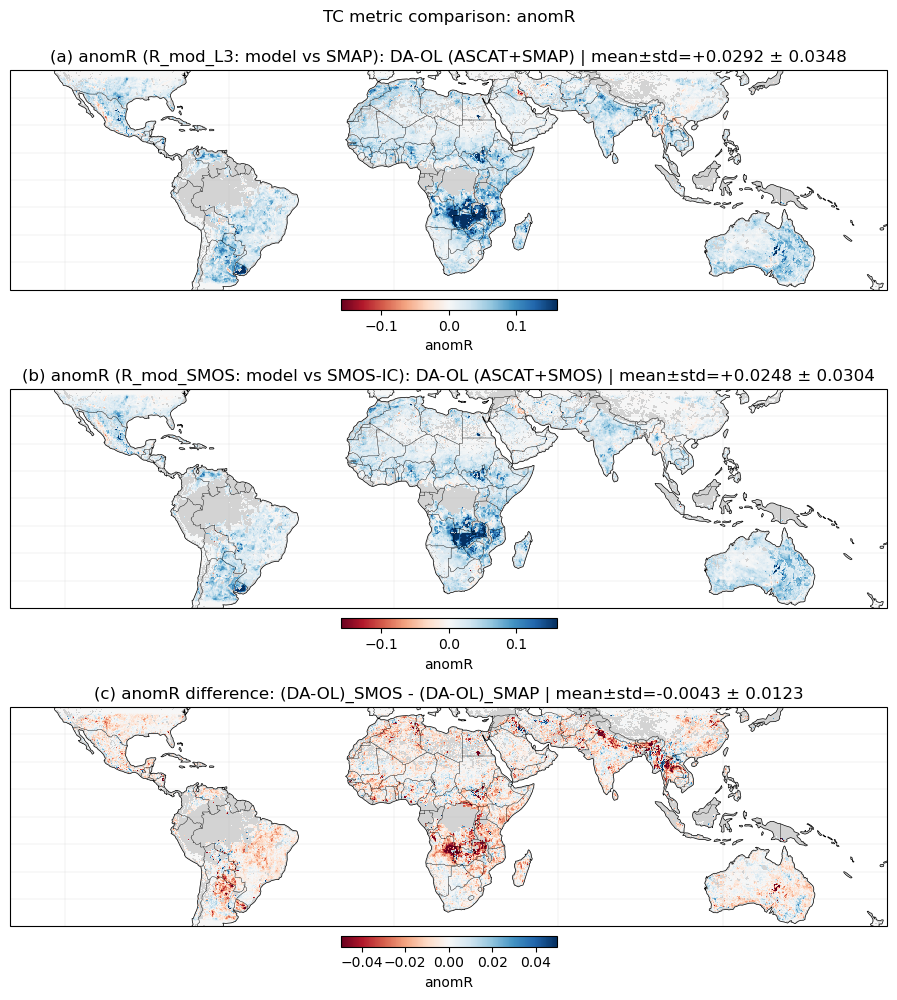

/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

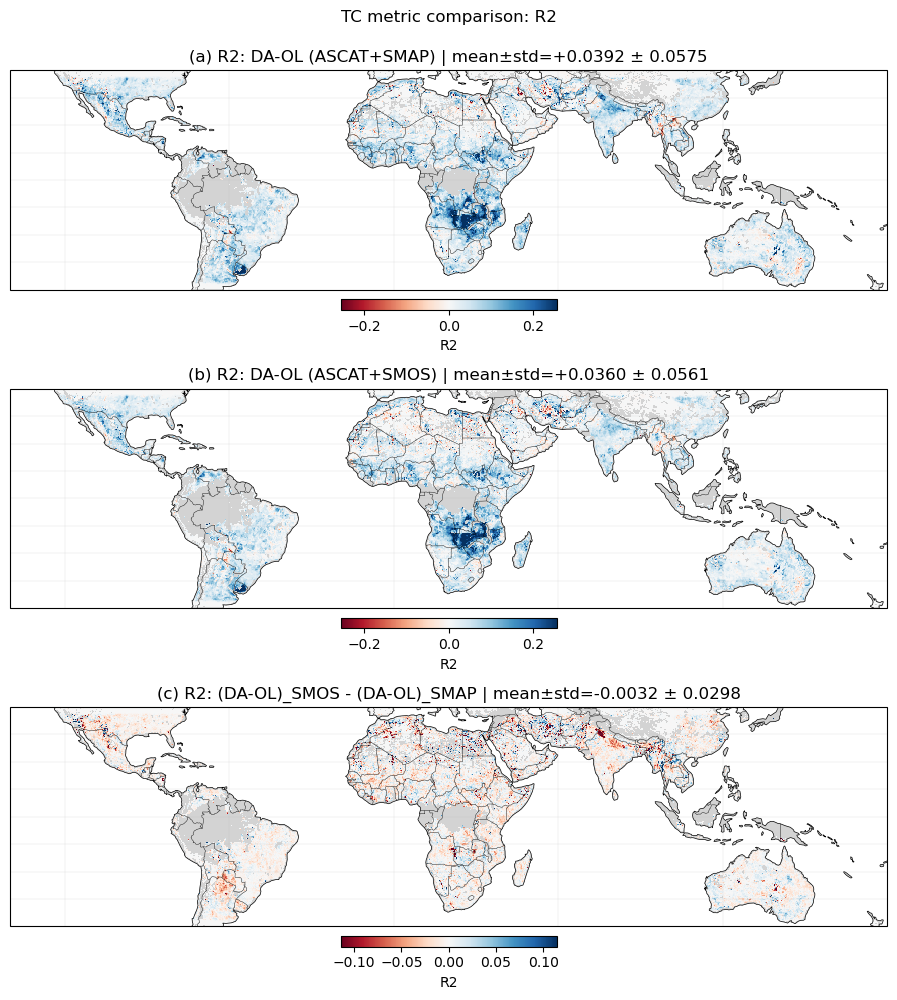

/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

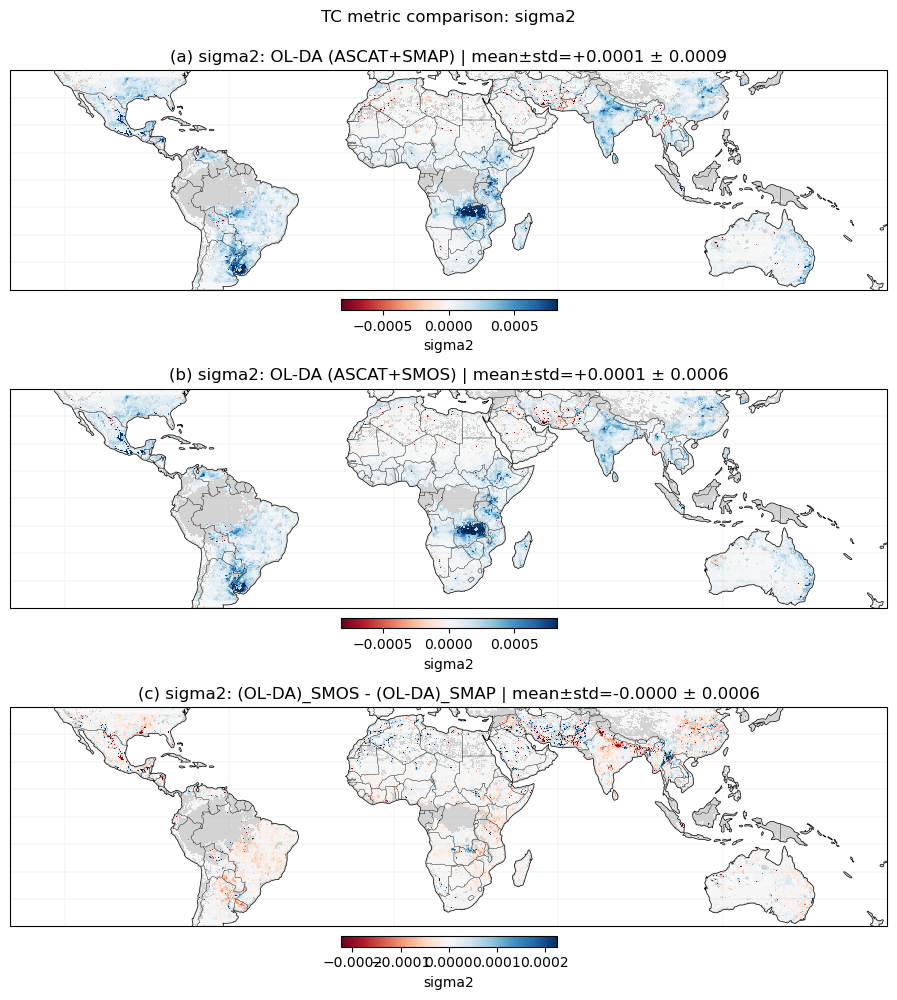

In [5]:
for metric in metrics:
    d_smap_plot = results[metric]['d_smap_plot']
    d_smos_plot = results[metric]['d_smos_plot']
    d_between_plot = results[metric]['d_between_plot']

    d_smap_stats = results[metric]['d_smap_full'] if STATS_ON_FULL_VALID_DOMAIN else d_smap_plot
    d_smos_stats = results[metric]['d_smos_full'] if STATS_ON_FULL_VALID_DOMAIN else d_smos_plot
    d_between_stats = results[metric]['d_between_full'] if STATS_ON_FULL_VALID_DOMAIN else d_between_plot

    label_main = results[metric]['label_main']

    vmax_main = robust_abs_limit(np.r_[d_smap_plot.reshape(-1), d_smos_plot.reshape(-1)], q=99)
    vmax_between = robust_abs_limit(d_between_plot, q=99)

    # Figure-6 style for sigma: RdBu so positive (improvement) is blue.
    cmap_metric = 'RdBu'

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

    if metric == 'anomR':
        title_a = f"(a) anomR (R_mod_L3: model vs SMAP): {label_main} (ASCAT+SMAP)"
        title_b = f"(b) anomR (R_mod_SMOS: model vs SMOS-IC): {label_main} (ASCAT+SMOS)"
        title_c = f"(c) anomR difference: ({label_main})_SMOS - ({label_main})_SMAP"
    else:
        title_a = f"(a) {metric}: {label_main} (ASCAT+SMAP)"
        title_b = f"(b) {metric}: {label_main} (ASCAT+SMOS)"
        title_c = f"(c) {metric}: ({label_main})_SMOS - ({label_main})_SMAP"

    panels = [
        (d_smap_plot, d_smap_stats, title_a, vmax_main),
        (d_smos_plot, d_smos_stats, title_b, vmax_main),
        (d_between_plot, d_between_stats, title_c, vmax_between),
    ]

    for ax, (arr_plot, arr_stats, ttl, vmax) in zip(axes, panels):
        m = ax.pcolormesh(
            lon_grid,
            lat_grid,
            arr_plot,
            transform=ccrs.PlateCarree(),
            cmap=cmap_metric,
            vmin=-vmax,
            vmax=vmax,
            shading='auto',
        )
        setup_map(ax, ttl + f" | mean±std={mean_pm_std_text(arr_stats, '+.4f', '.4f')}")
        cb = fig.colorbar(m, ax=ax, orientation='horizontal', pad=0.04, fraction=0.045)
        cb.set_label(metric)

    fig.suptitle(f"TC metric comparison: {metric}", y=0.995)
    plt.tight_layout()
    plt.show()


## OL Pair-Count Comparison (`N_sm`)

This section compares the number of paired samples per grid cell in **OL** between:
- ASCAT+SMAP (`ASCL4_SMPL3_CNTL`)
- ASCAT+SMOS-IC (`ASCL4_SMOSIC_OL`)


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

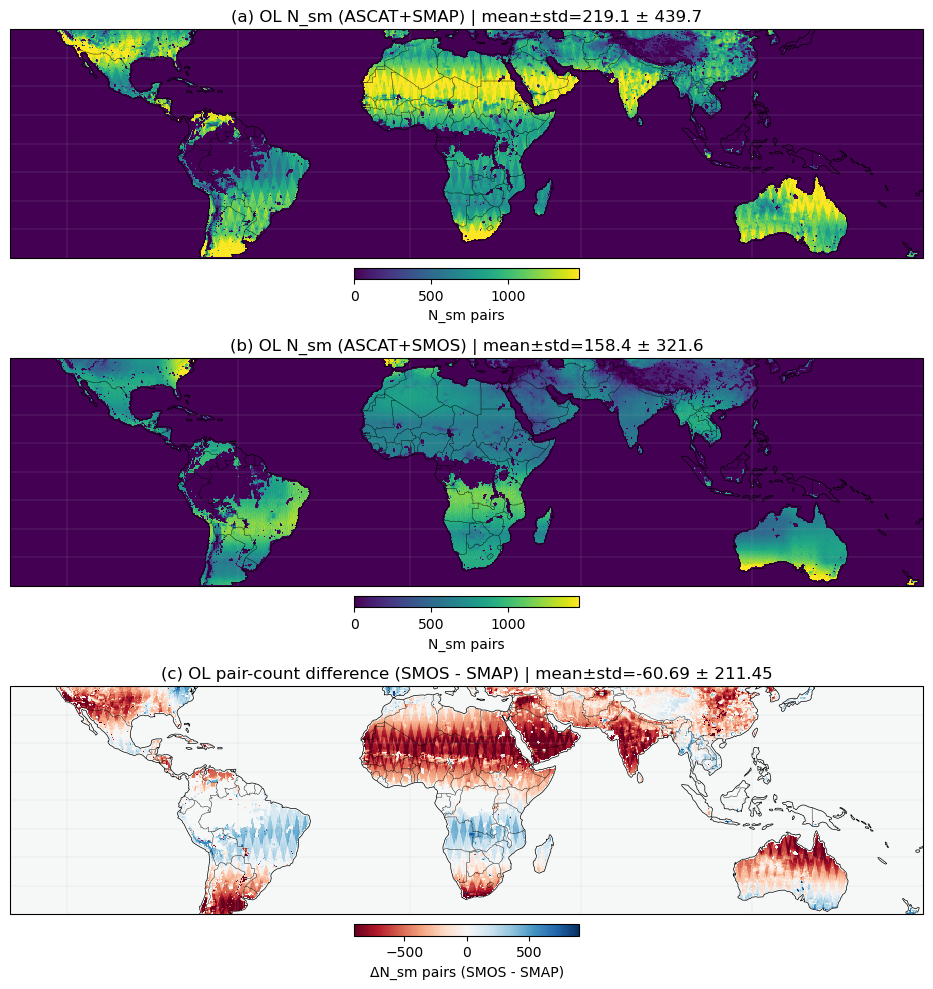

In [6]:
n_smap_ol = np.where(CYGNSS_DOMAIN_MASK, tc_smap_ol['N_sm'], np.nan)
n_smos_ol = np.where(CYGNSS_DOMAIN_MASK, tc_smos_ol['N_sm'], np.nan)

common_n = np.isfinite(n_smap_ol) & np.isfinite(n_smos_ol)
n_diff_ol = np.where(common_n, n_smos_ol - n_smap_ol, np.nan)

vmax_n = robust_abs_limit(np.r_[n_smap_ol.reshape(-1), n_smos_ol.reshape(-1)], q=99)
vmax_dn = robust_abs_limit(n_diff_ol, q=99)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

m0 = axes[0].pcolormesh(
    lon_grid, lat_grid, n_smap_ol,
    transform=ccrs.PlateCarree(), cmap='viridis', vmin=0, vmax=vmax_n, shading='auto'
)
setup_map(axes[0], f"(a) OL N_sm (ASCAT+SMAP) | mean±std={mean_pm_std_text(n_smap_ol, '.1f', '.1f')}")
cb0 = fig.colorbar(m0, ax=axes[0], orientation='horizontal', pad=0.04, fraction=0.045)
cb0.set_label('N_sm pairs')

m1 = axes[1].pcolormesh(
    lon_grid, lat_grid, n_smos_ol,
    transform=ccrs.PlateCarree(), cmap='viridis', vmin=0, vmax=vmax_n, shading='auto'
)
setup_map(axes[1], f"(b) OL N_sm (ASCAT+SMOS) | mean±std={mean_pm_std_text(n_smos_ol, '.1f', '.1f')}")
cb1 = fig.colorbar(m1, ax=axes[1], orientation='horizontal', pad=0.04, fraction=0.045)
cb1.set_label('N_sm pairs')

m2 = axes[2].pcolormesh(
    lon_grid, lat_grid, n_diff_ol,
    transform=ccrs.PlateCarree(), cmap='RdBu', vmin=-vmax_dn, vmax=vmax_dn, shading='auto'
)
setup_map(axes[2], f"(c) OL pair-count difference (SMOS - SMAP) | mean±std={mean_pm_std_text(n_diff_ol, '+.2f', '.2f')}")
cb2 = fig.colorbar(m2, ax=axes[2], orientation='horizontal', pad=0.04, fraction=0.045)
cb2.set_label('ΔN_sm pairs (SMOS - SMAP)')

plt.tight_layout()
plt.show()


## Sigma2 Percent Change (OL vs DA)

This uses percent change relative to OL:

\[%\Delta\sigma^2 = 100 \times (OL - DA) / OL\]

for each approach, plus the approach-to-approach difference.

/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

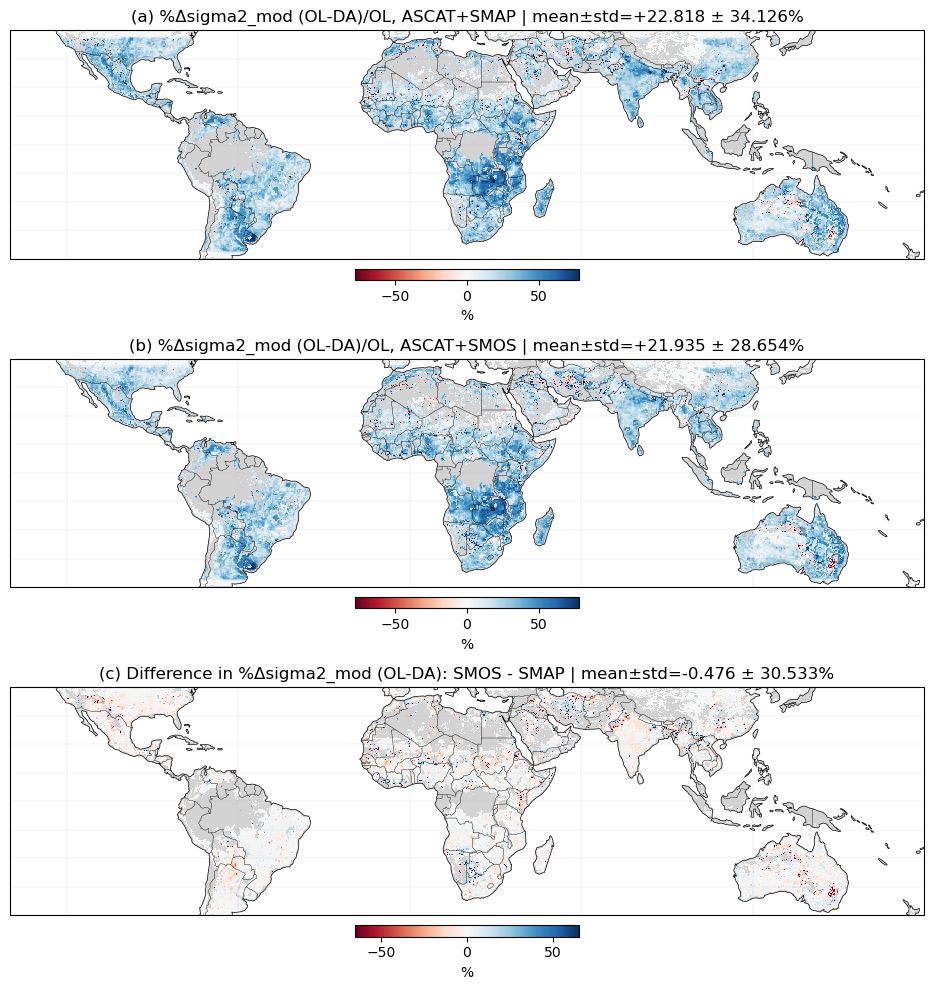

,map,n,mean,median,p05,p95
0,%Δsigma2 (OL-DA)/OL ASCAT+SMAP,42704,22.818244,22.265459,0.014218,52.300873
1,%Δsigma2 (OL-DA)/OL ASCAT+SMOS,42590,21.935028,21.346449,-0.019455,52.120480
2,Difference (SMOS - SMAP),40024,-0.476278,-0.240675,-11.279627,9.373620


In [7]:
sigma2_ol_smap = get_metric_grid(tc_smap_ol, 'sigma2', 'smap')
sigma2_da_smap = get_metric_grid(tc_smap_da, 'sigma2', 'smap')
sigma2_ol_smos = get_metric_grid(tc_smos_ol, 'sigma2', 'smos')
sigma2_da_smos = get_metric_grid(tc_smos_da, 'sigma2', 'smos')

# Figure-6-style shared-valid masks (Nmin + finite R2/sigma2)
valid_base_smap = common_valid_mask(tc_smap_ol, tc_smap_da)
valid_base_smos = common_valid_mask(tc_smos_ol, tc_smos_da)

# Figure-6 denominator protection: floor baseline sigma2 at max(1e-8, p10)
p10_smap = np.nanpercentile(sigma2_ol_smap, 10)
p10_smos = np.nanpercentile(sigma2_ol_smos, 10)
baseline_floor_smap = max(1e-8, p10_smap)
baseline_floor_smos = max(1e-8, p10_smos)

good_base_smap = valid_base_smap & np.isfinite(sigma2_ol_smap) & (sigma2_ol_smap > baseline_floor_smap)
good_base_smos = valid_base_smos & np.isfinite(sigma2_ol_smos) & (sigma2_ol_smos > baseline_floor_smos)

# Figure-6 convention: percent improvement as (OL - DA) / OL.
pct_smap_full = np.full_like(sigma2_ol_smap, np.nan, dtype=float)
pct_smos_full = np.full_like(sigma2_ol_smos, np.nan, dtype=float)
pct_smap_full[good_base_smap] = 100.0 * (sigma2_ol_smap[good_base_smap] - sigma2_da_smap[good_base_smap]) / sigma2_ol_smap[good_base_smap]
pct_smos_full[good_base_smos] = 100.0 * (sigma2_ol_smos[good_base_smos] - sigma2_da_smos[good_base_smos]) / sigma2_ol_smos[good_base_smos]

# Plot remains CYGNSS-domain-only
pct_smap_plot = np.where(CYGNSS_DOMAIN_MASK, pct_smap_full, np.nan)
pct_smos_plot = np.where(CYGNSS_DOMAIN_MASK, pct_smos_full, np.nan)

common_pct_full = np.isfinite(pct_smap_full) & np.isfinite(pct_smos_full)
pct_between_full = np.where(common_pct_full, pct_smos_full - pct_smap_full, np.nan)
pct_between_plot = np.where(CYGNSS_DOMAIN_MASK, pct_between_full, np.nan)

pct_smap_stats = pct_smap_full if STATS_ON_FULL_VALID_DOMAIN else pct_smap_plot
pct_smos_stats = pct_smos_full if STATS_ON_FULL_VALID_DOMAIN else pct_smos_plot
pct_between_stats = pct_between_full if STATS_ON_FULL_VALID_DOMAIN else pct_between_plot

vmax_pct = robust_abs_limit(np.r_[pct_smap_plot.reshape(-1), pct_smos_plot.reshape(-1)], q=99)
vmax_between = robust_abs_limit(pct_between_plot, q=99)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

panels = [
    (pct_smap_plot, pct_smap_stats, '(a) %Δsigma2_mod (OL-DA)/OL, ASCAT+SMAP', vmax_pct),
    (pct_smos_plot, pct_smos_stats, '(b) %Δsigma2_mod (OL-DA)/OL, ASCAT+SMOS', vmax_pct),
    (pct_between_plot, pct_between_stats, '(c) Difference in %Δsigma2_mod (OL-DA): SMOS - SMAP', vmax_between),
]

for ax, (arr_plot, arr_stats, ttl, vmax) in zip(axes, panels):
    m = ax.pcolormesh(
        lon_grid, lat_grid, arr_plot,
        transform=ccrs.PlateCarree(), cmap='RdBu',
        vmin=-vmax, vmax=vmax, shading='auto'
    )
    setup_map(ax, ttl + f" | mean±std={mean_pm_std_text(arr_stats, '+.3f', '.3f', '%')}")
    cb = fig.colorbar(m, ax=ax, orientation='horizontal', pad=0.04, fraction=0.045)
    cb.set_label('%')

plt.tight_layout()
plt.show()

pd.DataFrame([
    {'map': '%Δsigma2 (OL-DA)/OL ASCAT+SMAP', **masked_stats(pct_smap_full)},
    {'map': '%Δsigma2 (OL-DA)/OL ASCAT+SMOS', **masked_stats(pct_smos_full)},
    {'map': 'Difference (SMOS - SMAP)', **masked_stats(pct_between_full)},
])


## Notes

- `anomR` is mapped as:
  - `R_mod_L3` for ASCAT+SMAP files
  - `R_mod_SMOS` for ASCAT+SMOS-IC files
- `R2` is `R2_TC_mod` and is clamped to `(0, 1]` before differencing (Figure-6-style).
- `sigma2` is `sigma2_mod`.
- `Nmin` is overridden to `50` for comparability with Figure 6.
- `anomR` and `R2` use `DA-OL`; `sigma2` uses Figure-6 sign convention `OL-DA` so positive implies improvement.
- `%Δsigma2` uses Figure-6 denominator protection: baseline floor = `max(1e-8, p10(sigma2_OL))`.
- Plots are shown on CYGNSS extent, but mean/std can be computed on the full valid TC field when `STATS_ON_FULL_VALID_DOMAIN=True`.
- Cross-approach differences use the intersection of valid masks from both approaches.
